# Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# load the dataset

In [2]:
df = pd.read_csv("data/Churn Sampled.csv")

df = df[["Geography", "Gender","Card Type","Age","CreditScore","Tenure","Point Earned","Balance","EstimatedSalary", 
    "NumOfProducts","IsActiveMember","HasCrCard","Satisfaction Score","Exited"]]

# df = df[["Geography", "Gender","Card Type","Age","Complain","CreditScore","Tenure","Point Earned","Balance","EstimatedSalary", 
#     "NumOfProducts","IsActiveMember","HasCrCard","Satisfaction Score","Exited"]]

df.sample(10)

,Geography,Gender,Card Type,Age,CreditScore,Tenure,Point Earned,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,HasCrCard,Satisfaction Score,Exited
2718,France,Male,SILVER,33,631,7,715,0.00,58043.02,1,1,1,2,1
2316,Germany,Male,SILVER,38,613,9,599,67111.65,78566.64,1,0,1,3,1
3770,France,Female,SILVER,52,626,0,959,0.00,32159.46,2,0,1,3,1
769,Germany,Male,DIAMOND,32,520,5,483,110029.77,56246.69,1,0,1,4,0
126,Germany,Female,DIAMOND,34,588,10,300,129417.82,153727.32,1,0,1,3,0
3497,Germany,Female,DIAMOND,33,638,5,899,129335.65,56585.20,1,1,1,4,1
2163,Spain,Female,PLATINUM,34,750,9,563,112822.26,150401.53,1,0,0,2,1
1525,Spain,Male,GOLD,41,592,0,576,0.00,65906.07,2,0,1,4,0
2427,Germany,Female,GOLD,47,573,4,273,152522.47,164038.07,1,1,0,4,1
3983,Spain,Male,DIAMOND,51,753,4,956,79811.72,68260.27,2,1,0,1,1


# Split dependent & Independant Data

In [3]:
X = df.drop("Exited", axis = 1)
y = df["Exited"]

# Train, Validation and Test Split

In [4]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.8, stratify = y, random_state = 42)

In [5]:
xtrain.shape,xtest.shape, ytrain.shape, ytest.shape

((3310, 13), (828, 13), (3310,), (828,))

In [6]:
xtrain, xval, ytrain, yval = train_test_split(xtrain, ytrain, train_size = 0.85, 
                                            stratify = ytrain, random_state = 42)

In [7]:
xtrain.shape, xval.shape, ytrain.shape, yval.shape 

((2813, 13), (497, 13), (2813,), (497,))

# Preprocessing

## Encodings

In [8]:
for col in df.select_dtypes(include= "object").columns:
    print(col, ":",df[col].unique())

Geography : ['Germany' 'France' 'Spain']
Gender : ['Male' 'Female']
Card Type : ['GOLD' 'SILVER' 'PLATINUM' 'DIAMOND']


In [9]:
le_geography = LabelEncoder()
le_gender = LabelEncoder()
oe_crdtype = OrdinalEncoder(categories = [["SILVER", "GOLD", "DIAMOND", "PLATINUM"]])

# Geography
xtrain["Geography"] = le_geography.fit_transform(xtrain["Geography"])
xval["Geography"] = le_geography.transform(xval["Geography"])
xtest["Geography"] = le_geography.transform(xtest["Geography"])

# Gender
xtrain["Gender"] = le_gender.fit_transform(xtrain["Gender"])
xval["Gender"] = le_gender.transform(xval["Gender"])
xtest["Gender"] = le_gender.transform(xtest["Gender"])

# Card Type
xtrain["Card Type"] = oe_crdtype.fit_transform(xtrain[["Card Type"]])
xval["Card Type"] = oe_crdtype.transform(xval[["Card Type"]])
xtest["Card Type"] = oe_crdtype.transform(xtest[["Card Type"]])

## Scaling

In [10]:
# Age, CreditScore, Point Earned, Balance, EstimatedSalary
mms = MinMaxScaler()
xtrain[["Age", "CreditScore", "Point Earned", "Balance", "EstimatedSalary"]] \
            = mms.fit_transform(xtrain[["Age","CreditScore", "Point Earned", "Balance", "EstimatedSalary"]])
xval[["Age", "CreditScore", "Point Earned", "Balance", "EstimatedSalary"]] \
            = mms.transform(xval[["Age","CreditScore", "Point Earned", "Balance", "EstimatedSalary"]])
xtest[["Age", "CreditScore", "Point Earned", "Balance", "EstimatedSalary"]] \
            = mms.transform(xtest[["Age","CreditScore", "Point Earned", "Balance", "EstimatedSalary"]])

# Heat Maps

In [11]:
xtrain["Exited"] = ytrain
xval["Exited"] = yval
xtest["Exited"] = ytest

In [12]:
xtrain.to_csv("data/Churn Train.csv", index = False)
xval.to_csv("data/Churn Val.csv", index = False)
xtest.to_csv("data/Churn Test.csv", index = False)

<Axes: >

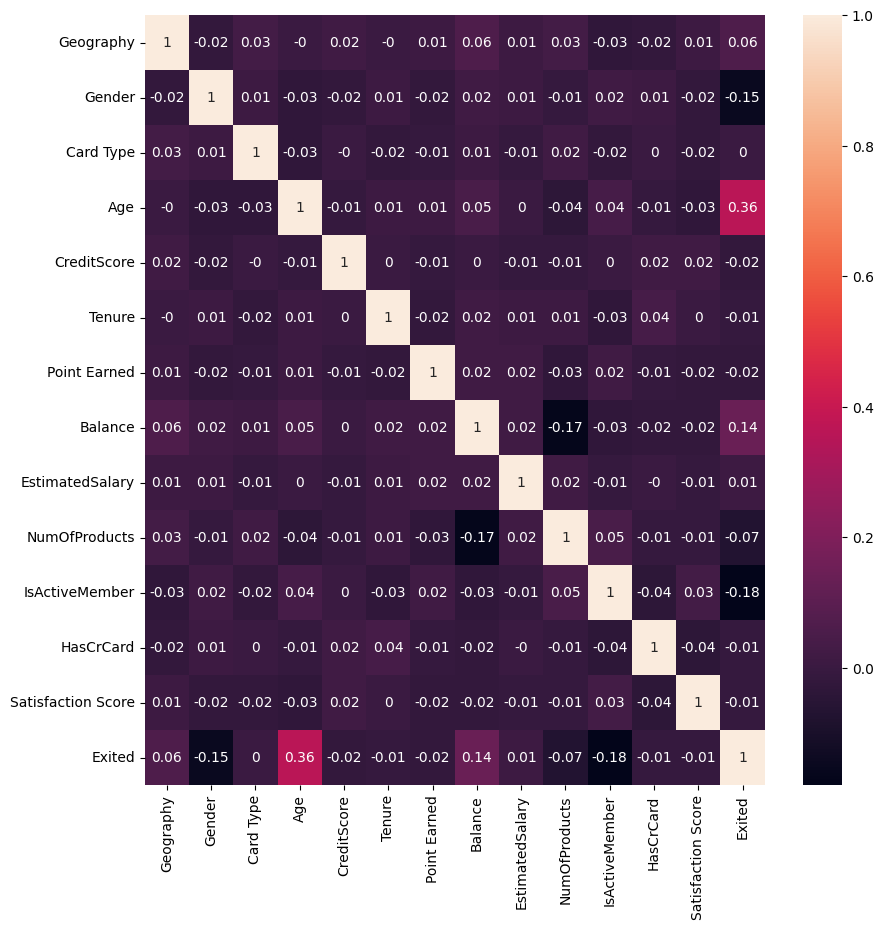

In [13]:
plt.figure(figsize = (10, 10))
sns.heatmap(xtrain.corr().round(2), annot=True)

<Axes: >

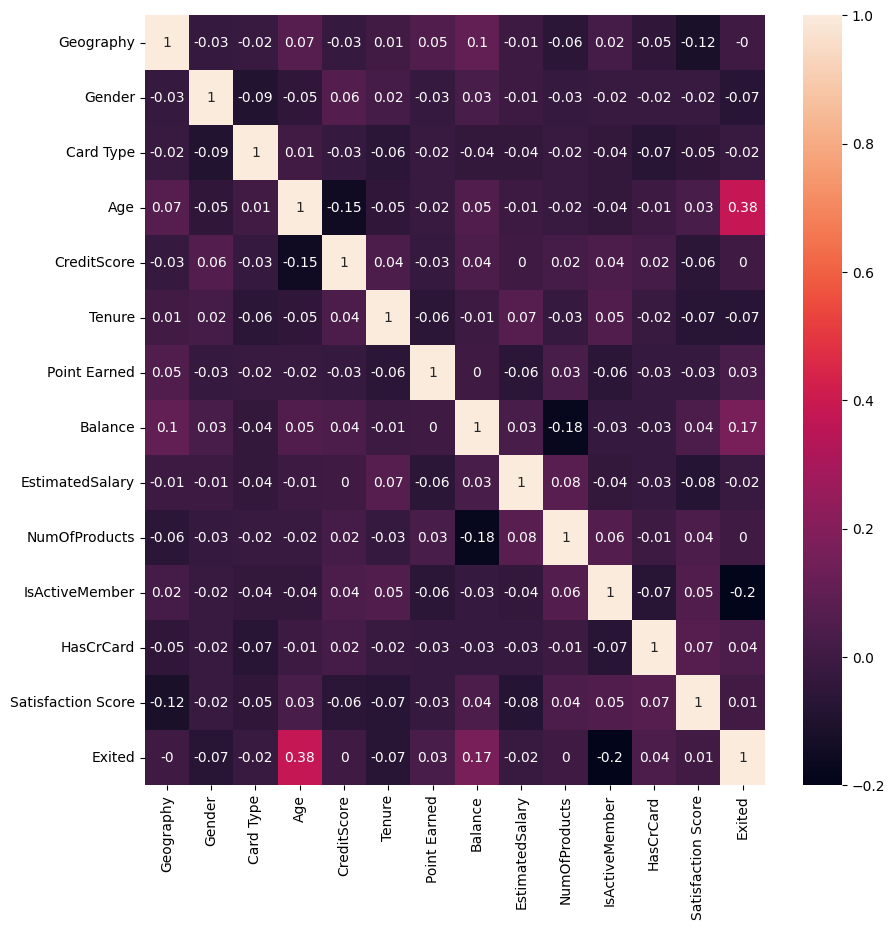

In [14]:
plt.figure(figsize = (10, 10))
sns.heatmap(xval.corr().round(2), annot=True)

<Axes: >

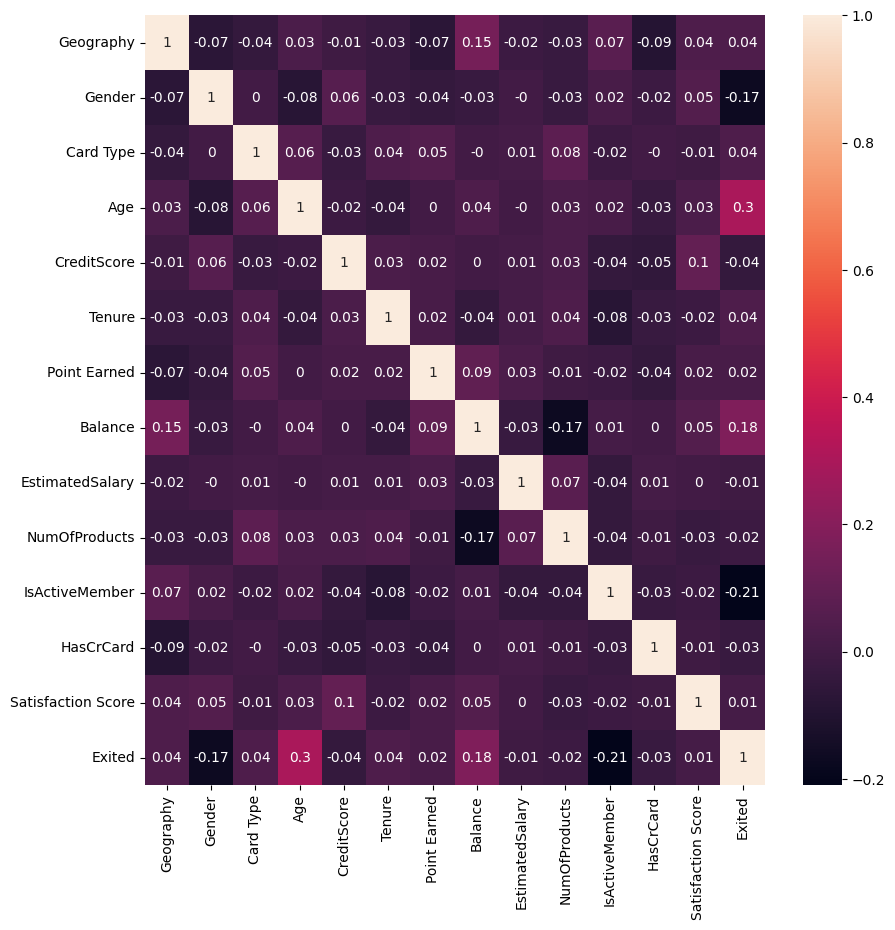

In [15]:
plt.figure(figsize = (10, 10))
sns.heatmap(xtest.corr().round(2), annot=True)

In [16]:
xtrain = xtrain.drop("Exited", axis = 1)
xval = xval.drop("Exited", axis = 1)
xtest = xtest.drop("Exited", axis = 1)

# Training on Base Models

In [17]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
gbc = GradientBoostingClassifier()
xgb = XGBClassifier()
gnb = GaussianNB()
svc = SVC()

In [18]:
models = [lr, dtc, rfc, abc, gbc, xgb, gnb, svc]
data = {
    "Train": (xtrain, ytrain),
    "Val": (xval, yval),
    "Test": (xtest, ytest)
}

metrics = {
    "Model": [],
    "Data Set": [],
    "Score": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
}

for model in models:
    model.fit(xtrain, ytrain)
    
    for set_name, (X, y) in data.items():
        preds = model.predict(X)

        acc = accuracy_score(y, preds)
        prec = precision_score(y, preds)
        rec = recall_score(y, preds)
        f1 = f1_score(y, preds)
        score = model.score(X, y)

        metrics["Model"].append(model.__class__.__name__)
        metrics["Data Set"].append(set_name)
        metrics["Score"].append(score)
        metrics["Accuracy"].append(acc)
        metrics["Precision"].append(prec)
        metrics["Recall"].append(rec)
        metrics["F1-score"].append(f1)

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Data Set,Score,Accuracy,Precision,Recall,F1-score
0,LogisticRegression,Train,0.703875,0.703875,0.703240,0.689531,0.696318
1,LogisticRegression,Val,0.686117,0.686117,0.701357,0.632653,0.665236
2,LogisticRegression,Test,0.701691,0.701691,0.705882,0.676471,0.690864
3,DecisionTreeClassifier,Train,1.000000,1.000000,1.000000,1.000000,1.000000
4,DecisionTreeClassifier,Val,0.680080,0.680080,0.673387,0.681633,0.677485
5,DecisionTreeClassifier,Test,0.705314,0.705314,0.716931,0.664216,0.689567
6,RandomForestClassifier,Train,0.999645,0.999645,0.999278,1.000000,0.999639
7,RandomForestClassifier,Val,0.752515,0.752515,0.756303,0.734694,0.745342
8,RandomForestClassifier,Test,0.781401,0.781401,0.794805,0.750000,0.771753
9,AdaBoostClassifier,Train,0.768219,0.768219,0.773712,0.748014,0.760646


In [19]:
metrics_df.to_csv("data/Model Metrics.csv", index = False)

# Hyper Parameter Tuning

In [ ]:
clf = GridSearchCV(estimator = GradientBoostingClassifier(), 
                   param_grid = {"n_estimators": [50, 100, 150, 200, 300], 
                                "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.2], 
                                "max_depth": [2, 3, 4, 5, 6, 7],
                                "subsample": [0.5, 0.7, 0.8, 1.0], 
                                "min_samples_split": [2, 4, 6, 8, 10] }, cv = 5)

clf.fit(xtrain, ytrain)

In [ ]:
model_params = {
    "GradientBoosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "n_estimators": [50, 100, 150, 200, 300],
            "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.2],
            "max_depth": [2, 3, 4, 5, 6, 7],
            "subsample": [0.5, 0.7, 0.8, 1.0],
            "min_samples_split": [2, 4, 6, 8, 10]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "params": {
            "n_estimators": [50, 100, 150, 200, 300],
            "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.2],
            "max_depth": [3, 4, 5, 6, 7, 8],
            "subsample": [0.5, 0.7, 0.8, 1.0],
            "colsample_bytree": [0.5, 0.7, 0.8, 1.0],
            "gamma": [0, 0.1, 0.2, 0.3, 0.5]
        }
    },
    "RandomForestClassifier": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [50, 100, 200, 300],
            "max_depth": [None, 10, 20, 30, 40],
            "min_samples_split": [2, 4, 6, 8, 10],
            "min_samples_leaf": [1, 2, 3, 4, 5],
            "max_features": ["auto", "sqrt", "log2"]
        }
    }
}


In [ ]:
gscv_scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=True)
    clf.fit(xtrain, ytrain)
    
    best_model = clf.best_estimator_
    
    train_acc = best_model.score(xtrain, ytrain)
    val_acc = best_model.score(xval, yval)
    test_acc = best_model.score(xtest, ytest)
    
    gscv_scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc
    })

df = pd.DataFrame(gscv_scores, columns=['model', 'best_score', 'best_params', 'train_acc', 'val_acc', 'test_acc'])
df


In [ ]:
df.to_csv("data/GridSearchCV Metrics.csv")